## Initiate and Dataset

In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle



In [2]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the test sets from SDF files
test_df = load_sdf_to_df(r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Eye Irritation\dataset\test_set_eye_irritation_features_rdkitcdk.sdf")

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

def string_to_list(descriptor):
    if isinstance(descriptor, str):
        return list(map(float, descriptor.strip('[]').split(',')))
    return descriptor

# Apply the function to the 'Modred_Descriptor' column
test_df['Modred_Descriptor'] = test_df['Modred_Descriptor'].apply(string_to_list)

# Convert 'Modred_Descriptor' column to a NumPy array
data_modred_test = np.array(test_df['Modred_Descriptor'].tolist())

print("Test DataFrame:")
print(test_df.head())


Test DataFrame:
  Outcome                                 Morgan_Descriptors  \
0       0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...   
2       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3       0  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor    ID  \
0  [0.04791643691944794, 0.800311806350089, 0.872...  2101   
1  [-0.47754646001907536, -0.8830342345716835, -0...   771   
2  [-0.13311749014425403, 1.5412168620442561, 0.9...   246   
3  [1.43297702

## Explotary Data

In [3]:
test_df.keys()

Index(['Outcome', 'Morgan_Descriptors', 'MACCS_Descriptors',
       'Modred_Descriptor', 'ID', 'SMILES', 'Molecular Weight', 'logP',
       'LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD',
       'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v',
       'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha',
       'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', 'MLogP',
       'nAtomP', 'naAromAtom', 'bpol', 'nB', 'ECCEN', 'fragC', 'nHBAcc',
       'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB',
       'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3'],
      dtype='object')

In [4]:
test_df

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,TPSA,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.04791643691944794, 0.800311806350089, 0.872...",2101,c1ccc2c(c1)Nc1ccccc1S2,199.045570288,3.894800000000001,87.15563838100506,12.03,...,1.0,0.0,0.0,0.4285714285714285,0.0,0.0,37.33,5.0,3.786000000000001,0.0
1,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.47754646001907536, -0.8830342345716835, -0...",771,CCCCOCCOC(C)=O,160.109944372,1.3662,67.68245838766332,35.53,...,0.0,4.0,10.0,0.4444444444444444,7.0,0.0,35.53,4.321928094887363,1.4010000000000002,0.875
2,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.13311749014425403, 1.5412168620442561, 0.9...",246,CC1C2C=CC1C1C(=O)OC(=O)C21,178.06299418,0.7541,75.75322299422147,43.370000000000005,...,0.0,0.0,0.0,0.4,0.0,0.0,43.370000000000005,4.906890595608519,1.0360000000000005,0.6
3,0,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.4329770243453508, 1.4600477358178132, 1.433...",2039,CCC(=O)Oc1ccc2c(c1)CCC1C2CCC2(C)C(OC(=O)CC)CCC12,384.23005950399994,5.179900000000005,167.5330023771495,52.6,...,0.0,3.0,4.0,0.5,6.0,1.0,52.6,5.954196310386876,5.668999999999998,0.6666666666666666
4,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0667527615400418, -1.8164144119861068, -1....",571,CCCCN,73.08914935199999,0.7452000000000001,33.17396806803209,26.02,...,1.0,4.0,5.0,0.5,2.0,0.0,26.02,3.0,0.784,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452,1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2558786798324313, -0.35899275450198626, -0...",536,C=CC(=O)OCC(CC)CCCC,184.14632988,2.9320000000000013,80.97413646916202,26.3,...,0.0,7.0,10.0,0.4444444444444444,8.0,0.0,26.3,4.584962500721156,3.887,0.7272727272727273
453,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.7759514461808201, 1.4789448908321114, 1.570...",2111,CC12CCC3C(CCC4=CC(=O)C=CC43C)C1CCC(=O)O2,300.17254462799997,3.5899000000000028,131.34226783807748,43.370000000000005,...,0.0,0.0,0.0,0.4545454545454545,0.0,0.0,43.370000000000005,5.643856189774724,3.683,0.6842105263157895
454,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7492313462684232, -0.8306082062863062, -0....",1624,C=C(C#N)CCC#N,106.053098192,1.36996,48.659517930565755,47.58,...,0.0,5.0,7.0,0.5,2.0,0.0,47.58,3.807354922057604,-0.0179999999999999,0.3333333333333333
455,1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8171655860141539, -0.6271691854741691, -0....",464,CCC(C)OC(C)=O,116.083729624,1.3479999999999999,49.83902892936324,26.3,...,0.0,4.0,6.0,0.4,3.0,0.0,26.3,3.807354922057604,1.4820000000000002,0.8333333333333334


In [5]:
test_df = test_df.rename(columns={'Outcome': 'Outcome'})

In [6]:
test_df= test_df.sort_values(['Outcome'], ascending=True)
#moldf['RowID'] = moldf.index
test_df.head(100)

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,TPSA,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.04791643691944794, 0.800311806350089, 0.872...",2101,c1ccc2c(c1)Nc1ccccc1S2,199.045570288,3.894800000000001,87.15563838100506,12.03,...,1.0,0.0,0.0,0.4285714285714285,0.0,0.0,37.33,5.0,3.786000000000001,0.0
375,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.25014201490384613, 0.3787487110664767, 0.4...",2105,CC[N+](C)(C)Cc1ccccc1Br,242.05388806409,3.0454000000000017,89.09346645392004,0.0,...,0.0,2.0,4.0,0.4285714285714285,3.0,0.0,0.0,4.700439718141093,2.803,0.4545454545454545
178,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.788399316301848, -0.8542147590372908, -0.83...",1186,CCCCCCCCCCCCCCCCCCCCCCO,326.35486609199995,7.800600000000008,147.19726918235438,20.23,...,1.0,22.0,23.0,0.5,20.0,2.0,20.23,5.459431618637297,11.093000000000004,1.0
179,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8246546821741206, -0.788580992353336, -0.7...",1417,CC(=O)OCC(C)C,116.083729624,1.2055,49.83902892936323,26.3,...,0.0,3.0,6.0,0.4,3.0,0.0,26.3,3.807354922057604,1.319,0.8333333333333334
372,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.43891279084130047, -0.20770642468642303, -0...",1351,CCCCC(CC)COC(=O)OCC(CC)CCCC,286.250794948,5.572400000000006,124.9669374172328,35.53,...,0.0,7.0,15.0,0.5,14.0,2.0,35.53,5.247927513443585,7.119999999999999,0.9411764705882352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.739548432578458, 0.6231803655504822, 0.6896...",1435,Cc1cccc(Cc2ccccc2)c1Cc1ccccc1,272.15650064,5.176620000000004,126.64041787481489,0.0,...,0.0,0.0,0.0,0.4545454545454545,4.0,1.0,0.0,5.523561956057013,6.391,0.1428571428571428
266,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.2905532634779706, 1.7861486348773434, 1.764...",2148,CC(=O)OC1(C(C)=O)CCC2C3C=C(C)C4=CC(=O)CCC4(C)C...,384.230059504,4.575300000000005,167.32850051010428,60.440000000000005,...,0.0,2.0,3.0,0.5,3.0,0.0,60.440000000000005,5.954196310386876,4.049,0.7083333333333334
263,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.37779552785841425, -0.8830342345716826, -0....",1265,CCCCCCCCC=CCCCCCCCCO,268.276615772,6.0162000000000075,121.04789769258367,20.23,...,1.0,18.0,19.0,0.5,15.0,2.0,20.23,5.169925001442312,8.301,0.8888888888888888
224,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.6591994500047212, 0.6588320262229757, 0.726...",1875,CC[N+](C)(C)C(C)CC(c1ccccc1)c1ccccc1,282.22162631609,4.693400000000004,129.3778393975326,0.0,...,0.0,4.0,6.0,0.4444444444444444,6.0,0.0,0.0,5.459431618637297,4.471,0.4


## Data Distribution

Classes                          :  ['0' '1']
Number of cpds in each class     :  [223, 234]
Total number of cpds             :  457
Class mapping:  {0: 0, 1: 1}


{0: 0, 1: 1}

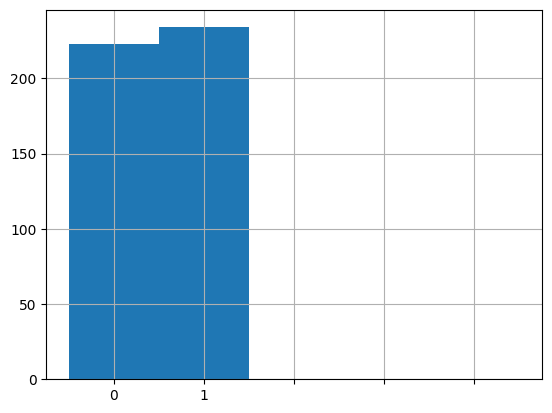

In [7]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Create the label encoder
le = LabelEncoder()

# Get unique outcomes
outcomes = np.unique(test_df['Outcome'])
le.fit(list(set(outcomes)))

# Transform the 'Outcome' column
y = le.transform(test_df['Outcome'])

# Print class information
print("Classes                          : ", outcomes)
print("Number of cpds in each class     : ", [len(y[y == smi]) for smi in np.unique(y)])
print("Total number of cpds             : ", len(y))

# Explicitly map the outcome classes
S = test_df['Outcome']

# Ensure the class mapping is applied explicitly and consistently
info = {0: 0, 1: 1}  # Ensure '0' is mapped to 0 and '1' is mapped to 1
S = S.replace(info)

# Print the class replacement info for reference
print("Class mapping: ", info)


#graph
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info




In [8]:
test_df

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,TPSA,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.04791643691944794, 0.800311806350089, 0.872...",2101,c1ccc2c(c1)Nc1ccccc1S2,199.045570288,3.894800000000001,87.15563838100506,12.03,...,1.0,0.0,0.0,0.4285714285714285,0.0,0.0,37.33,5.0,3.786000000000001,0.0
375,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.25014201490384613, 0.3787487110664767, 0.4...",2105,CC[N+](C)(C)Cc1ccccc1Br,242.05388806409,3.0454000000000017,89.09346645392004,0.0,...,0.0,2.0,4.0,0.4285714285714285,3.0,0.0,0.0,4.700439718141093,2.803,0.4545454545454545
178,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.788399316301848, -0.8542147590372908, -0.83...",1186,CCCCCCCCCCCCCCCCCCCCCCO,326.35486609199995,7.800600000000008,147.19726918235438,20.23,...,1.0,22.0,23.0,0.5,20.0,2.0,20.23,5.459431618637297,11.093000000000004,1.0
179,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8246546821741206, -0.788580992353336, -0.7...",1417,CC(=O)OCC(C)C,116.083729624,1.2055,49.83902892936323,26.3,...,0.0,3.0,6.0,0.4,3.0,0.0,26.3,3.807354922057604,1.319,0.8333333333333334
372,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.43891279084130047, -0.20770642468642303, -0...",1351,CCCCC(CC)COC(=O)OCC(CC)CCCC,286.250794948,5.572400000000006,124.9669374172328,35.53,...,0.0,7.0,15.0,0.5,14.0,2.0,35.53,5.247927513443585,7.119999999999999,0.9411764705882352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.2594996877202358, -0.3870431626392465, -0.3...",1091,CCCCCCCCCCCC(=O)OOC(=O)CCCCCCCCCCC,398.339609952,7.829600000000009,173.6123496337912,52.6,...,0.0,12.0,26.0,0.48,23.0,2.0,52.6,5.754887502163469,10.634000000000002,0.9166666666666666
209,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9332454506985439, 0.49420738439285267, 0.55...",110,CCC(C)=NO[Si](ON=C(C)CC)(ON=C(C)CC)ON=C(C)CC,372.219282034,4.632000000000004,151.9393089641687,86.36,...,0.0,4.0,11.0,0.5,12.0,2.0,86.36,5.584962500721157,5.231999999999999,0.75
207,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8281554438780846, 0.03353380012611593, -0....",74,Cc1nccn1C,96.06874825599999,0.72852,42.80006723684632,17.82,...,0.0,0.0,0.0,0.3333333333333333,0.0,0.0,17.82,3.807354922057604,0.502,0.4
203,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5902447527987297, -0.21717699472312912, -0...",471,O=C=Nc1ccccc1,119.03711378,1.6539,52.85318981979746,29.43,...,0.0,0.0,3.0,0.5,1.0,0.0,29.43,4.169925001442312,3.2860000000000005,0.0


## Data Cleansing and Preproc

In [9]:
x_rdkitcdk = test_df.drop(columns=['Outcome', 'Morgan_Descriptors', 'MACCS_Descriptors',
       'Modred_Descriptor', 'ID', 'SMILES', 'Molecular Weight', 'logP'])

In [10]:
print(x_rdkitcdk)

              LabuteASA   TPSA                 AMW NumLipinskiHBA  \
0     87.15563838100506  12.03             199.278              2   
375   89.09346645392004    0.0  243.16799999999998              0   
178  147.19726918235438  20.23  326.60900000000004              1   
179   49.83902892936323   26.3              116.16              2   
372   124.9669374172328  35.53             286.456              3   
..                  ...    ...                 ...            ...   
210   173.6123496337912   52.6   398.6280000000004              4   
209   151.9393089641687  86.36  372.54200000000014              8   
207   42.80006723684632  17.82              96.133              2   
203   52.85318981979746  29.43  119.12299999999995              2   
456    78.1216554413723   74.6  210.27599999999998              4   

    NumLipinskiHBD NumRotatableBonds NumHBD NumHBA NumAmideBonds  \
0                1                 0      1      2             0   
375              0                 

In [11]:
x_rdkitcdk  = x_rdkitcdk.apply(lambda row: row.values, axis=1).tolist()

# Add the new column 'rdkit_cdk' to test_df
test_df['rdkit_cdk'] = x_rdkitcdk 

# Display the updated DataFrame
print(test_df)

    Outcome                                 Morgan_Descriptors  \
0         0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
375       0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
178       0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
179       0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...   
372       0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
..      ...                                                ...   
210       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
209       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
207       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
203       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
456       1  [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                     MACCS_Descriptors  \
0    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
375  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
178  [0, 0, 0, 0, 0, 0, 0, 0, 0, 

## Data Initiate

In [12]:
y_test= np.int32((S))
x_test_morgan = np.array(list(test_df['Morgan_Descriptors']))
x_test_macckeys = np.array(list(test_df['MACCS_Descriptors']))
x_test_modred= np.array(list(test_df['Modred_Descriptor']))
x_test_rdkit_cdk = np.array(list(test_df['rdkit_cdk']))

In [13]:
x_test_rdkit_cdk

array([['87.15563838100506', '12.03', '199.278', ..., '5.0',
        '3.786000000000001', '0.0'],
       ['89.09346645392004', '0.0', '243.16799999999998', ...,
        '4.700439718141093', '2.803', '0.4545454545454545'],
       ['147.19726918235438', '20.23', '326.60900000000004', ...,
        '5.459431618637297', '11.093000000000004', '1.0'],
       ...,
       ['42.80006723684632', '17.82', '96.133', ..., '3.807354922057604',
        '0.502', '0.4'],
       ['52.85318981979746', '29.43', '119.12299999999995', ...,
        '4.169925001442312', '3.2860000000000005', '0.0'],
       ['78.1216554413723', '74.6', '210.27599999999998', ...,
        '4.459431618637298', '0.5159999999999998', '0.6666666666666666']],
      dtype=object)

In [14]:
import joblib
import numpy as np
import ast

# Function to ensure data is a NumPy array
def ensure_numpy_array(data):
    if isinstance(data, np.ndarray):
        return data
    elif isinstance(data, list):
        return np.array(data)
    elif hasattr(data, 'to_numpy'):  # For Pandas DataFrame
        return data.to_numpy()
    else:
        raise ValueError("Data format not recognized. Ensure it is a list, numpy array, or pandas DataFrame.")

# Function to check if all elements are numerical
def check_numerical(data):
    if not np.issubdtype(data.dtype, np.number):
        raise ValueError("Data contains non-numerical values. Ensure all elements are numerical.")

# Function to convert string representations of lists to numerical arrays
def parse_string_lists(data):
    parsed_data = []
    for item in data:
        if isinstance(item, str):
            try:
                parsed_item = ast.literal_eval(item)
                parsed_data.append(parsed_item)
            except (ValueError, SyntaxError):
                raise ValueError(f"Cannot parse value '{item}'")
        else:
            parsed_data.append(item)
    return np.array(parsed_data)

# Ensure training data is properly formatted
x_test_morgan = ensure_numpy_array(x_test_morgan)
x_test_macckeys = ensure_numpy_array(x_test_macckeys)
x_test_modred = ensure_numpy_array(x_test_modred)

check_numerical(x_test_morgan)
check_numerical(x_test_macckeys)

# Parse and convert string lists in x_test_modred
x_test_modred = parse_string_lists(x_test_modred)
check_numerical(x_test_modred)





In [15]:
x_test = np.concatenate((x_test_morgan, x_test_macckeys, x_test_modred), axis=1)

## Load .pkl Model

In [16]:
# load code
# load model - all included
import joblib

# Base paths
desc_path = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Eye Irritation\model\fingerprint descriptor model"
phys_path = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Eye Irritation\model\physical chemical properties model"

# descriptor
rf_morgan   = joblib.load(fr"{desc_path}\Model_Eye_RF_morgan.pkl")  
rf_maccs    = joblib.load(fr"{desc_path}\Model_Eye_RF_maccskey.pkl")
rf_modred   = joblib.load(fr"{desc_path}\Model_Eye_RF_modred.pkl")

svm_morgan  = joblib.load(fr"{desc_path}\Model_Eye_SVM_morgan.pkl")  
svm_maccs   = joblib.load(fr"{desc_path}\Model_Eye_SVM_maccskey.pkl")
svm_modred  = joblib.load(fr"{desc_path}\Model_Eye_SVM_modred.pkl")

xgb_morgan  = joblib.load(fr"{desc_path}\Model_Eye_XGB_morgan.pkl")  
xgb_maccs   = joblib.load(fr"{desc_path}\Model_Eye_XGB_maccskey.pkl")
xgb_modred  = joblib.load(fr"{desc_path}\Model_Eye_XGB_modred.pkl")

nn_morgan   = joblib.load(fr"{desc_path}\Model_Eye_NN_morgan.pkl")  
nn_maccs    = joblib.load(fr"{desc_path}\Model_Eye_NN_maccskey.pkl")
nn_modred   = joblib.load(fr"{desc_path}\Model_Eye_NN_modred.pkl")

lgbm_morgan = joblib.load(fr"{desc_path}\Model_Eye_LGBM_morgan.pkl")  
lgbm_maccs  = joblib.load(fr"{desc_path}\Model_Eye_LGBM_maccskey.pkl")
lgbm_modred = joblib.load(fr"{desc_path}\Model_Eye_LGBM_modred.pkl")

# physiochemical
rf_p   = joblib.load(fr"{phys_path}\Model_Eye_RF_phys.pkl")
svm_p  = joblib.load(fr"{phys_path}\Model_Eye_SVM_phys.pkl")
xgb_p  = joblib.load(fr"{phys_path}\Model_Eye_XGB_phys.pkl")
nn_p   = joblib.load(fr"{phys_path}\Model_Eye_NN_phys.pkl")
lgbm_p = joblib.load(fr"{phys_path}\Model_Eye_LGBM_phys.pkl")


In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score, classification_report
y_true = test_df['Outcome'].astype(int)  # Ensure it's of integer type, suitable for metrics calculation


In [21]:
x_test

array([[ 0.        ,  0.        ,  0.        , ...,  0.08968031,
         0.17568409, -0.25575465],
       [ 0.        ,  0.        ,  0.        , ..., -0.18307812,
        -0.17942806, -0.30644114],
       [ 0.        ,  0.        ,  0.        , ...,  0.28450777,
         0.07883532,  1.08743731],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -0.76756049,
        -0.71209629, -0.91467901],
       [ 0.        ,  0.        ,  0.        , ..., -0.65066402,
        -0.63138898, -0.6232317 ],
       [ 1.        ,  0.        ,  0.        , ..., -0.49480205,
        -0.56682314, -0.31911276]])

## Physiochemical Consensus and Individual

In [22]:
#Default

import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):
  
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]  # Probabilities for class 1
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]  # Probabilities for class 1
    svm_probs_rdkitcdk = svm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]  # Probabilities for class 1
    
    # Calculate the mean probability across RF and XGB models
    mean_probs = np.mean([rf_probs_rdkitcdk, xgb_probs_rdkitcdk], axis=0)
    
    # Convert mean probabilities to final class predictions (e.g., threshold at 0.5)
    final_predictions = (mean_probs > 0.5).astype(int)
    
    return final_predictions, mean_probs, rf_probs_rdkitcdk, xgb_probs_rdkitcdk, svm_probs_rdkitcdk

# Run prediction
final_predictions, mean_probs, rf_probs, xgb_probs, svm_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['RF_Probabilities'] = rf_probs
test_df['XGB_Probabilities'] = xgb_probs
test_df['SVM_Probabilities'] = svm_probs

y_true = test_df['Outcome'].astype(int)  

conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix (Consensus):")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy (Consensus):", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score (Consensus):", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')  
print("F1 Score (Consensus):", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity (Consensus):", sensitivity)
print("Specificity (Consensus):", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate) (Consensus):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp)
print("PPV (Positive Predictive Value) (Consensus):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn)
print("NPV (Negative Predictive Value) (Consensus):", npv)

# Evaluate RF model alone
rf_predictions = (rf_probs > 0.5).astype(int)
conf_matrix_rf = confusion_matrix(y_true, rf_predictions)
print("Confusion Matrix (RF):")
print(conf_matrix_rf)

accuracy_rf = accuracy_score(y_true, rf_predictions)
print("Accuracy (RF):", accuracy_rf)

auc_score_rf = roc_auc_score(y_true, rf_probs)
print("AUC Score (RF):", auc_score_rf)

f1_rf = f1_score(y_true, rf_predictions, average='binary')
print("F1 Score (RF):", f1_rf)

tn, fp, fn, tp = conf_matrix_rf.ravel()
sensitivity_rf = tp / (tp + fn)
specificity_rf = tn / (tn + fp)
print("Sensitivity (RF):", sensitivity_rf)
print("Specificity (RF):", specificity_rf)

ccr_rf = (sensitivity_rf + specificity_rf) / 2
print("CCR (Correct Classification Rate) (RF):", ccr_rf)

ppv_rf = tp / (tp + fp)
print("PPV (Positive Predictive Value) (RF):", ppv_rf)

npv_rf = tn / (tn + fn)
print("NPV (Negative Predictive Value) (RF):", npv_rf)

# Evaluate XGB model alone
xgb_predictions = (xgb_probs > 0.5).astype(int)
conf_matrix_xgb = confusion_matrix(y_true, xgb_predictions)
print("Confusion Matrix (XGB):")
print(conf_matrix_xgb)

accuracy_xgb = accuracy_score(y_true, xgb_predictions)
print("Accuracy (XGB):", accuracy_xgb)

auc_score_xgb = roc_auc_score(y_true, xgb_probs)
print("AUC Score (XGB):", auc_score_xgb)

f1_xgb = f1_score(y_true, xgb_predictions, average='binary')
print("F1 Score (XGB):", f1_xgb)

tn, fp, fn, tp = conf_matrix_xgb.ravel()
sensitivity_xgb = tp / (tp + fn)
specificity_xgb = tn / (tn + fp)
print("Sensitivity (XGB):", sensitivity_xgb)
print("Specificity (XGB):", specificity_xgb)

ccr_xgb = (sensitivity_xgb + specificity_xgb) / 2
print("CCR (Correct Classification Rate) (XGB):", ccr_xgb)

ppv_xgb = tp / (tp + fp)
print("PPV (Positive Predictive Value) (XGB):", ppv_xgb)

npv_xgb = tn / (tn + fn)
print("NPV (Negative Predictive Value) (XGB):", npv_xgb)

# Evaluate SVM model alone
svm_predictions = (svm_probs > 0.5).astype(int)
conf_matrix_svm = confusion_matrix(y_true, svm_predictions)
print("Confusion Matrix (SVM):")
print(conf_matrix_svm)

accuracy_svm = accuracy_score(y_true, svm_predictions)
print("Accuracy (SVM):", accuracy_svm)

auc_score_svm = roc_auc_score(y_true, svm_probs)
print("AUC Score (SVM):", auc_score_svm)

f1_svm = f1_score(y_true, svm_predictions, average='binary')
print("F1 Score (SVM):", f1_svm)

tn, fp, fn, tp = conf_matrix_svm.ravel()
sensitivity_svm = tp / (tp + fn)
specificity_svm = tn / (tn + fp)
print("Sensitivity (SVM):", sensitivity_svm)
print("Specificity (SVM):", specificity_svm)

ccr_svm = (sensitivity_svm + specificity_svm) / 2
print("CCR (Correct Classification Rate) (SVM):", ccr_svm)

ppv_svm = tp / (tp + fp)
print("PPV (Positive Predictive Value) (SVM):", ppv_svm)

npv_svm = tn / (tn + fn)
print("NPV (Negative Predictive Value) (SVM):", npv_svm)

Confusion Matrix (Consensus):
[[155  68]
 [ 62 172]]
Accuracy (Consensus): 0.7155361050328227
AUC Score (Consensus): 0.7968648192863439
F1 Score (Consensus): 0.7257383966244726
Sensitivity (Consensus): 0.7350427350427351
Specificity (Consensus): 0.695067264573991
CCR (Correct Classification Rate) (Consensus): 0.7150549998083631
PPV (Positive Predictive Value) (Consensus): 0.7166666666666667
NPV (Negative Predictive Value) (Consensus): 0.7142857142857143
Confusion Matrix (RF):
[[155  68]
 [ 64 170]]
Accuracy (RF): 0.7111597374179431
AUC Score (RF): 0.7955616879383696
F1 Score (RF): 0.7203389830508474
Sensitivity (RF): 0.7264957264957265
Specificity (RF): 0.695067264573991
CCR (Correct Classification Rate) (RF): 0.7107814955348588
PPV (Positive Predictive Value) (RF): 0.7142857142857143
NPV (Negative Predictive Value) (RF): 0.7077625570776256
Confusion Matrix (XGB):
[[157  66]
 [ 67 167]]
Accuracy (XGB): 0.7089715536105032
AUC Score (XGB): 0.7832585949177877
F1 Score (XGB): 0.71520342612

In [23]:
#best choice maybe
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):
    X_test = np.array(test_df['rdkit_cdk'].tolist())

    rf_probs = rf_p.predict_proba(X_test)[:, 1]
    xgb_probs = xgb_p.predict_proba(X_test)[:, 1]
    svm_probs = svm_p.predict_proba(X_test)[:, 1]
    nn_probs = nn_p.predict_proba(X_test)[:, 1]
    lgbm_probs = lgbm_p.predict_proba(X_test)[:, 1]

    # Calculate the mean probability across all 5 models
    mean_probs = np.mean([rf_probs, xgb_probs, svm_probs, nn_probs, lgbm_probs], axis=0)

    # Convert mean probabilities to final class predictions (threshold at 0.5)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs, rf_probs, xgb_probs, svm_probs, nn_probs, lgbm_probs

# Run prediction
final_predictions, mean_probs, rf_probs, xgb_probs, svm_probs, nn_probs, lgbm_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['RF_Probabilities'] = rf_probs
test_df['XGB_Probabilities'] = xgb_probs
test_df['SVM_Probabilities'] = svm_probs
test_df['NN_Probabilities'] = nn_probs
test_df['LGBM_Probabilities'] = lgbm_probs

y_true = test_df['Outcome'].astype(int)


def evaluate_model(y_true, probs, label):
    predictions = (probs > 0.5).astype(int)
    cm = confusion_matrix(y_true, predictions)
    print(f"Confusion Matrix ({label}):")
    print(cm)

    accuracy = accuracy_score(y_true, predictions)
    print(f"Accuracy ({label}):", accuracy)

    auc_score = roc_auc_score(y_true, probs)
    print(f"AUC Score ({label}):", auc_score)

    f1 = f1_score(y_true, predictions, average='binary')
    print(f"F1 Score ({label}):", f1)

    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    print(f"Sensitivity ({label}):", sensitivity)
    print(f"Specificity ({label}):", specificity)

    ccr = (sensitivity + specificity) / 2
    print(f"CCR (Correct Classification Rate) ({label}):", ccr)

    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"PPV (Positive Predictive Value) ({label}):", ppv)

    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    print(f"NPV (Negative Predictive Value) ({label}):", npv)

    print()  # spacer antar model
    return {
        "accuracy": accuracy, "auc": auc_score, "f1": f1,
        "sensitivity": sensitivity, "specificity": specificity,
        "ccr": ccr, "ppv": ppv, "npv": npv
    }


# Evaluate consensus and each individual model
results_consensus = evaluate_model(y_true, mean_probs, "Consensus")
results_rf = evaluate_model(y_true, rf_probs, "RF")
results_xgb = evaluate_model(y_true, xgb_probs, "XGB")
results_svm = evaluate_model(y_true, svm_probs, "SVM")
results_nn = evaluate_model(y_true, nn_probs, "NN")
results_lgbm = evaluate_model(y_true, lgbm_probs, "LGBM")

Confusion Matrix (Consensus):
[[150  73]
 [ 56 178]]
Accuracy (Consensus): 0.7177242888402626
AUC Score (Consensus): 0.7972480932122187
F1 Score (Consensus): 0.734020618556701
Sensitivity (Consensus): 0.7606837606837606
Specificity (Consensus): 0.672645739910314
CCR (Correct Classification Rate) (Consensus): 0.7166647502970374
PPV (Positive Predictive Value) (Consensus): 0.7091633466135459
NPV (Negative Predictive Value) (Consensus): 0.7281553398058253

Confusion Matrix (RF):
[[155  68]
 [ 64 170]]
Accuracy (RF): 0.7111597374179431
AUC Score (RF): 0.7955616879383696
F1 Score (RF): 0.7203389830508474
Sensitivity (RF): 0.7264957264957265
Specificity (RF): 0.695067264573991
CCR (Correct Classification Rate) (RF): 0.7107814955348588
PPV (Positive Predictive Value) (RF): 0.7142857142857143
NPV (Negative Predictive Value) (RF): 0.7077625570776256

Confusion Matrix (XGB):
[[157  66]
 [ 67 167]]
Accuracy (XGB): 0.7089715536105032
AUC Score (XGB): 0.7832585949177877
F1 Score (XGB): 0.7152034261

## Consensus Physiochemical and Mol Desc

In [24]:
#Persis dengan bu yunen
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = rf_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = rf_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, xgb_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
y_true = test_df['Outcome'].astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[158  65]
 [ 58 176]]
Accuracy: 0.7308533916849015
AUC Score: 0.8023648001226477
F1 Score: 0.7410526315789474
Sensitivity: 0.7521367521367521
Specificity: 0.7085201793721974
CCR (Correct Classification Rate): 0.7303284657544747
PPV (Positive Predictive Value): 0.7302904564315352
NPV (Negative Predictive Value): 0.7314814814814815


## Best - RF XGB SVM

In [25]:
#rf xgb svm(p) rf(p)
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = xgb_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = svm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, xgb_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
y_true = test_df['Outcome'].astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[161  62]
 [ 61 173]]
Accuracy: 0.7308533916849015
AUC Score: 0.7986470430416618
F1 Score: 0.7377398720682303
Sensitivity: 0.7393162393162394
Specificity: 0.7219730941704036
CCR (Correct Classification Rate): 0.7306446667433215
PPV (Positive Predictive Value): 0.7361702127659574
NPV (Negative Predictive Value): 0.7252252252252253


In [26]:
#best
# rf xgb svm nn(p) lgbm(p)
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = xgb_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = svm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    nn_probs_rdkitcdk = nn_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs_rdkitcdk = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, lgbm_probs_rdkitcdk, nn_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
y_true = test_df['Outcome'].astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[154  69]
 [ 54 180]]
Accuracy: 0.7308533916849015
AUC Score: 0.8020965083745354
F1 Score: 0.7453416149068323
Sensitivity: 0.7692307692307693
Specificity: 0.6905829596412556
CCR (Correct Classification Rate): 0.7299068644360125
PPV (Positive Predictive Value): 0.7228915662650602
NPV (Negative Predictive Value): 0.7403846153846154


## Read Acrcross

In [ ]:
test_df = load_sdf_to_df(r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Eye Irritation\dataset\test_set_eye_irritation_features_rdkitcdk.sdf")


In [27]:
#Read-Across (Tanimoto Similarity, Morgan Fingerprint, k=5, weighted) - Eye

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
from rdkit import DataStructs
from rdkit.DataStructs import ExplicitBitVect

# ===== Load train_df =====
train_df = load_sdf_to_df(r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Eye Irritation\dataset\test_set_eye_irritation_features_rdkitcdk.sdf")

def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string


train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)

print("Train DataFrame:")
print(train_df.head())
print(train_df.shape)


# ===== Fungsi Read-Across =====
def tanimoto_similarity_matrix(query_fps, ref_fps):
    n_query = query_fps.shape[0]
    n_ref = ref_fps.shape[0]
    sim_matrix = np.zeros((n_query, n_ref))

    ref_bitvecs = []
    for row in ref_fps:
        bv = ExplicitBitVect(len(row))
        on_bits = np.where(row == 1)[0].tolist()
        bv.SetBitsFromList(on_bits)
        ref_bitvecs.append(bv)

    for i, q_row in enumerate(query_fps):
        q_bv = ExplicitBitVect(len(q_row))
        q_on_bits = np.where(q_row == 1)[0].tolist()
        q_bv.SetBitsFromList(q_on_bits)
        sims = DataStructs.BulkTanimotoSimilarity(q_bv, ref_bitvecs)
        sim_matrix[i, :] = sims

    return sim_matrix


def read_across_predict(X_test_fp, X_train_fp, y_train, k=5):
    sim_matrix = tanimoto_similarity_matrix(X_test_fp, X_train_fp)
    predictions_proba = np.zeros(X_test_fp.shape[0])

    for i in range(X_test_fp.shape[0]):
        sims = sim_matrix[i, :]
        top_k_idx = np.argsort(sims)[::-1][:k]
        top_k_sims = sims[top_k_idx]
        top_k_labels = y_train[top_k_idx]

        total_sim = np.sum(top_k_sims)
        if total_sim > 0:
            weighted_pred = np.sum(top_k_sims * top_k_labels) / total_sim
        else:
            weighted_pred = np.mean(top_k_labels)
        predictions_proba[i] = weighted_pred

    return predictions_proba


# ===== Siapkan data =====
X_train_morgan = np.array(train_df['Morgan_Descriptors'].tolist())
y_train = pd.to_numeric(train_df['Outcome'], errors='coerce').astype(int).values

X_test_morgan = np.array(test_df['Morgan_Descriptors'].tolist())
y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# ===== Jalankan read-across =====
readacross_probs = read_across_predict(X_test_morgan, X_train_morgan, y_train, k=5)
readacross_predictions = (readacross_probs > 0.5).astype(int)

test_df['ReadAcross_Probabilities'] = readacross_probs
test_df['ReadAcross_Predictions'] = readacross_predictions

# ===== Evaluasi =====
conf_matrix_ra = confusion_matrix(y_true, readacross_predictions)
print("Confusion Matrix (Read-Across):")
print(conf_matrix_ra)

accuracy_ra = accuracy_score(y_true, readacross_predictions)
print("Accuracy (Read-Across):", accuracy_ra)

auc_score_ra = roc_auc_score(y_true, readacross_probs)
print("AUC Score (Read-Across):", auc_score_ra)

f1_ra = f1_score(y_true, readacross_predictions, average='binary')
print("F1 Score (Read-Across):", f1_ra)

tn, fp, fn, tp = conf_matrix_ra.ravel()
sensitivity_ra = tp / (tp + fn)
specificity_ra = tn / (tn + fp)
print("Sensitivity (Read-Across):", sensitivity_ra)
print("Specificity (Read-Across):", specificity_ra)

ccr_ra = (sensitivity_ra + specificity_ra) / 2
print("CCR (Correct Classification Rate) (Read-Across):", ccr_ra)

ppv_ra = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value) (Read-Across):", ppv_ra)

npv_ra = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value) (Read-Across):", npv_ra)

Train DataFrame:
  Outcome                                 Morgan_Descriptors  \
0       0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...   
2       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3       0  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor    ID  \
0  [0.04791643691944794, 0.800311806350089, 0.872...  2101   
1  [-0.47754646001907536, -0.8830342345716835, -0...   771   
2  [-0.13311749014425403, 1.5412168620442561, 0.9...   246   
3  [1.4329770

In [28]:
#Read-Across (Tanimoto Similarity, Morgan Fingerprint, k=5, weighted) - Eye

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
from rdkit import DataStructs
from rdkit.DataStructs import ExplicitBitVect

# ===== Load train_df =====
train_df = load_sdf_to_df(r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Eye Irritation\dataset\test_set_eye_irritation_features_rdkitcdk.sdf")

def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string


train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)

print("Train DataFrame:")
print(train_df.head())
print(train_df.shape)


# ===== Fungsi Read-Across =====
def tanimoto_similarity_matrix(query_fps, ref_fps):
    n_query = query_fps.shape[0]
    n_ref = ref_fps.shape[0]
    sim_matrix = np.zeros((n_query, n_ref))

    ref_bitvecs = []
    for row in ref_fps:
        bv = ExplicitBitVect(len(row))
        on_bits = np.where(row == 1)[0].tolist()
        bv.SetBitsFromList(on_bits)
        ref_bitvecs.append(bv)

    for i, q_row in enumerate(query_fps):
        q_bv = ExplicitBitVect(len(q_row))
        q_on_bits = np.where(q_row == 1)[0].tolist()
        q_bv.SetBitsFromList(q_on_bits)
        sims = DataStructs.BulkTanimotoSimilarity(q_bv, ref_bitvecs)
        sim_matrix[i, :] = sims

    return sim_matrix


def read_across_predict(X_test_fp, X_train_fp, y_train, k=5):
    sim_matrix = tanimoto_similarity_matrix(X_test_fp, X_train_fp)
    predictions_proba = np.zeros(X_test_fp.shape[0])

    for i in range(X_test_fp.shape[0]):
        sims = sim_matrix[i, :]
        top_k_idx = np.argsort(sims)[::-1][:k]
        top_k_sims = sims[top_k_idx]
        top_k_labels = y_train[top_k_idx]

        total_sim = np.sum(top_k_sims)
        if total_sim > 0:
            weighted_pred = np.sum(top_k_sims * top_k_labels) / total_sim
        else:
            weighted_pred = np.mean(top_k_labels)
        predictions_proba[i] = weighted_pred

    return predictions_proba


# ===== Siapkan data =====
X_train_morgan = np.array(train_df['MACCS_Descriptors'].tolist())
y_train = pd.to_numeric(train_df['Outcome'], errors='coerce').astype(int).values

X_test_morgan = np.array(test_df['MACCS_Descriptors'].tolist())
y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# ===== Jalankan read-across =====
readacross_probs = read_across_predict(X_test_morgan, X_train_morgan, y_train, k=5)
readacross_predictions = (readacross_probs > 0.5).astype(int)

test_df['ReadAcross_Probabilities'] = readacross_probs
test_df['ReadAcross_Predictions'] = readacross_predictions

# ===== Evaluasi =====
conf_matrix_ra = confusion_matrix(y_true, readacross_predictions)
print("Confusion Matrix MACCS (Read-Across):")
print(conf_matrix_ra)

accuracy_ra = accuracy_score(y_true, readacross_predictions)
print("Accuracy (Read-Across):", accuracy_ra)

auc_score_ra = roc_auc_score(y_true, readacross_probs)
print("AUC Score (Read-Across):", auc_score_ra)

f1_ra = f1_score(y_true, readacross_predictions, average='binary')
print("F1 Score (Read-Across):", f1_ra)

tn, fp, fn, tp = conf_matrix_ra.ravel()
sensitivity_ra = tp / (tp + fn)
specificity_ra = tn / (tn + fp)
print("Sensitivity (Read-Across):", sensitivity_ra)
print("Specificity (Read-Across):", specificity_ra)

ccr_ra = (sensitivity_ra + specificity_ra) / 2
print("CCR (Correct Classification Rate) (Read-Across):", ccr_ra)

ppv_ra = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value) (Read-Across):", ppv_ra)

npv_ra = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value) (Read-Across):", npv_ra)

Train DataFrame:
  Outcome                                 Morgan_Descriptors  \
0       0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...   
2       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3       0  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor    ID  \
0  [0.04791643691944794, 0.800311806350089, 0.872...  2101   
1  [-0.47754646001907536, -0.8830342345716835, -0...   771   
2  [-0.13311749014425403, 1.5412168620442561, 0.9...   246   
3  [1.4329770

## QRASAR Morgan

In [29]:
#rf xgb svm(p) rf(p) + read-across
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
from rdkit import DataStructs
from rdkit.DataStructs import ExplicitBitVect

# ===== Fungsi Read-Across =====
def tanimoto_similarity_matrix(query_fps, ref_fps):
    n_query = query_fps.shape[0]
    n_ref = ref_fps.shape[0]
    sim_matrix = np.zeros((n_query, n_ref))

    ref_bitvecs = []
    for row in ref_fps:
        bv = ExplicitBitVect(len(row))
        on_bits = np.where(row == 1)[0].tolist()
        bv.SetBitsFromList(on_bits)
        ref_bitvecs.append(bv)

    for i, q_row in enumerate(query_fps):
        q_bv = ExplicitBitVect(len(q_row))
        q_on_bits = np.where(q_row == 1)[0].tolist()
        q_bv.SetBitsFromList(q_on_bits)
        sims = DataStructs.BulkTanimotoSimilarity(q_bv, ref_bitvecs)
        sim_matrix[i, :] = sims

    return sim_matrix


def read_across_predict(X_test_fp, X_train_fp, y_train, k=5):
    sim_matrix = tanimoto_similarity_matrix(X_test_fp, X_train_fp)
    predictions_proba = np.zeros(X_test_fp.shape[0])

    for i in range(X_test_fp.shape[0]):
        sims = sim_matrix[i, :]
        top_k_idx = np.argsort(sims)[::-1][:k]
        top_k_sims = sims[top_k_idx]
        top_k_labels = y_train[top_k_idx]

        total_sim = np.sum(top_k_sims)
        if total_sim > 0:
            weighted_pred = np.sum(top_k_sims * top_k_labels) / total_sim
        else:
            weighted_pred = np.mean(top_k_labels)
        predictions_proba[i] = weighted_pred

    return predictions_proba


# ===== Fungsi konsensus utama =====
def predict_with_models_probabilities(test_df, train_df, k_readacross=5):
    morgan_probs = lgbm_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = lgbm_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = lgbm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs_rdkitcdk = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    svm_probs_rdkitcdk = svm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # ----- Read-Across -----
    X_train_morgan = np.array(train_df['Morgan_Descriptors'].tolist())
    y_train_ra = pd.to_numeric(train_df['Outcome'], errors='coerce').astype(int).values
    X_test_morgan = np.array(test_df['Morgan_Descriptors'].tolist())

    readacross_probs = read_across_predict(X_test_morgan, X_train_morgan, y_train_ra, k=k_readacross)

    # ----- Konsensus (7 komponen) -----
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs,lgbm_probs_rdkitcdk, svm_probs_rdkitcdk, rf_probs_rdkitcdk,
    readacross_probs,readacross_probs
    ], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs, readacross_probs


# Run prediction
final_predictions, mean_probs, readacross_probs = predict_with_models_probabilities(test_df, train_df, k_readacross=5)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['ReadAcross_Probabilities'] = readacross_probs

y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[172  51]
 [ 44 190]]
Accuracy: 0.7921225382932167
AUC Score: 0.8885631060518953
F1 Score: 0.8
Sensitivity: 0.811965811965812
Specificity: 0.7713004484304933
CCR (Correct Classification Rate): 0.7916331301981526
PPV (Positive Predictive Value): 0.7883817427385892
NPV (Negative Predictive Value): 0.7962962962962963


In [30]:
#rf xgb svm(p) rf(p) + read-across
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
from rdkit import DataStructs
from rdkit.DataStructs import ExplicitBitVect

# ===== Fungsi Read-Across =====
def tanimoto_similarity_matrix(query_fps, ref_fps):
    n_query = query_fps.shape[0]
    n_ref = ref_fps.shape[0]
    sim_matrix = np.zeros((n_query, n_ref))

    ref_bitvecs = []
    for row in ref_fps:
        bv = ExplicitBitVect(len(row))
        on_bits = np.where(row == 1)[0].tolist()
        bv.SetBitsFromList(on_bits)
        ref_bitvecs.append(bv)

    for i, q_row in enumerate(query_fps):
        q_bv = ExplicitBitVect(len(q_row))
        q_on_bits = np.where(q_row == 1)[0].tolist()
        q_bv.SetBitsFromList(q_on_bits)
        sims = DataStructs.BulkTanimotoSimilarity(q_bv, ref_bitvecs)
        sim_matrix[i, :] = sims

    return sim_matrix


def read_across_predict(X_test_fp, X_train_fp, y_train, k=5):
    sim_matrix = tanimoto_similarity_matrix(X_test_fp, X_train_fp)
    predictions_proba = np.zeros(X_test_fp.shape[0])

    for i in range(X_test_fp.shape[0]):
        sims = sim_matrix[i, :]
        top_k_idx = np.argsort(sims)[::-1][:k]
        top_k_sims = sims[top_k_idx]
        top_k_labels = y_train[top_k_idx]

        total_sim = np.sum(top_k_sims)
        if total_sim > 0:
            weighted_pred = np.sum(top_k_sims * top_k_labels) / total_sim
        else:
            weighted_pred = np.mean(top_k_labels)
        predictions_proba[i] = weighted_pred

    return predictions_proba


# ===== Fungsi konsensus utama =====
def predict_with_models_probabilities(test_df, train_df, k_readacross=5):
    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = xgb_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = svm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # ----- Read-Across -----
    X_train_morgan = np.array(train_df['Morgan_Descriptors'].tolist())
    y_train_ra = pd.to_numeric(train_df['Outcome'], errors='coerce').astype(int).values
    X_test_morgan = np.array(test_df['Morgan_Descriptors'].tolist())

    readacross_probs = read_across_predict(X_test_morgan, X_train_morgan, y_train_ra, k=k_readacross)

    # ----- Konsensus (7 komponen) -----
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs,rf_probs_rdkitcdk, xgb_probs_rdkitcdk,
    readacross_probs,readacross_probs
    ], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs, readacross_probs


# Run prediction
final_predictions, mean_probs, readacross_probs = predict_with_models_probabilities(test_df, train_df, k_readacross=5)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['ReadAcross_Probabilities'] = readacross_probs

y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[174  49]
 [ 36 198]]
Accuracy: 0.8140043763676149
AUC Score: 0.9073243647234679
F1 Score: 0.8232848232848233
Sensitivity: 0.8461538461538461
Specificity: 0.7802690582959642
CCR (Correct Classification Rate): 0.8132114522249052
PPV (Positive Predictive Value): 0.8016194331983806
NPV (Negative Predictive Value): 0.8285714285714286


## QRASAR Maccs keys

In [31]:
#rf xgb svm(p) rf(p) + read-across
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
from rdkit import DataStructs
from rdkit.DataStructs import ExplicitBitVect

# ===== Fungsi Read-Across =====
def tanimoto_similarity_matrix(query_fps, ref_fps):
    n_query = query_fps.shape[0]
    n_ref = ref_fps.shape[0]
    sim_matrix = np.zeros((n_query, n_ref))

    ref_bitvecs = []
    for row in ref_fps:
        bv = ExplicitBitVect(len(row))
        on_bits = np.where(row == 1)[0].tolist()
        bv.SetBitsFromList(on_bits)
        ref_bitvecs.append(bv)

    for i, q_row in enumerate(query_fps):
        q_bv = ExplicitBitVect(len(q_row))
        q_on_bits = np.where(q_row == 1)[0].tolist()
        q_bv.SetBitsFromList(q_on_bits)
        sims = DataStructs.BulkTanimotoSimilarity(q_bv, ref_bitvecs)
        sim_matrix[i, :] = sims

    return sim_matrix


def read_across_predict(X_test_fp, X_train_fp, y_train, k=5):
    sim_matrix = tanimoto_similarity_matrix(X_test_fp, X_train_fp)
    predictions_proba = np.zeros(X_test_fp.shape[0])

    for i in range(X_test_fp.shape[0]):
        sims = sim_matrix[i, :]
        top_k_idx = np.argsort(sims)[::-1][:k]
        top_k_sims = sims[top_k_idx]
        top_k_labels = y_train[top_k_idx]

        total_sim = np.sum(top_k_sims)
        if total_sim > 0:
            weighted_pred = np.sum(top_k_sims * top_k_labels) / total_sim
        else:
            weighted_pred = np.mean(top_k_labels)
        predictions_proba[i] = weighted_pred

    return predictions_proba


# ===== Fungsi konsensus utama =====
def predict_with_models_probabilities(test_df, train_df, k_readacross=5):
    morgan_probs = lgbm_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = lgbm_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = lgbm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs_rdkitcdk = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    svm_probs_rdkitcdk = svm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # ----- Read-Across -----
    X_train_maccs = np.array(train_df['MACCS_Descriptors'].tolist())
    y_train_ra = pd.to_numeric(train_df['Outcome'], errors='coerce').astype(int).values
    X_test_maccs = np.array(test_df['MACCS_Descriptors'].tolist())

    readacross_probs = read_across_predict(X_test_maccs, X_train_maccs, y_train_ra, k=k_readacross)

    # ----- Konsensus (7 komponen) -----
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs,lgbm_probs_rdkitcdk, svm_probs_rdkitcdk, rf_probs_rdkitcdk,
    readacross_probs,readacross_probs
    ], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs, readacross_probs


# Run prediction
final_predictions, mean_probs, readacross_probs = predict_with_models_probabilities(test_df, train_df, k_readacross=5)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['ReadAcross_Probabilities'] = readacross_probs

y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[171  52]
 [ 50 184]]
Accuracy: 0.7768052516411379
AUC Score: 0.866754819669618
F1 Score: 0.7829787234042553
Sensitivity: 0.7863247863247863
Specificity: 0.7668161434977578
CCR (Correct Classification Rate): 0.7765704649112721
PPV (Positive Predictive Value): 0.7796610169491526
NPV (Negative Predictive Value): 0.7737556561085973


In [32]:
#rf xgb svm(p) rf(p) + read-across
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
from rdkit import DataStructs
from rdkit.DataStructs import ExplicitBitVect

# ===== Fungsi Read-Across =====
def tanimoto_similarity_matrix(query_fps, ref_fps):
    n_query = query_fps.shape[0]
    n_ref = ref_fps.shape[0]
    sim_matrix = np.zeros((n_query, n_ref))

    ref_bitvecs = []
    for row in ref_fps:
        bv = ExplicitBitVect(len(row))
        on_bits = np.where(row == 1)[0].tolist()
        bv.SetBitsFromList(on_bits)
        ref_bitvecs.append(bv)

    for i, q_row in enumerate(query_fps):
        q_bv = ExplicitBitVect(len(q_row))
        q_on_bits = np.where(q_row == 1)[0].tolist()
        q_bv.SetBitsFromList(q_on_bits)
        sims = DataStructs.BulkTanimotoSimilarity(q_bv, ref_bitvecs)
        sim_matrix[i, :] = sims

    return sim_matrix


def read_across_predict(X_test_fp, X_train_fp, y_train, k=5):
    sim_matrix = tanimoto_similarity_matrix(X_test_fp, X_train_fp)
    predictions_proba = np.zeros(X_test_fp.shape[0])

    for i in range(X_test_fp.shape[0]):
        sims = sim_matrix[i, :]
        top_k_idx = np.argsort(sims)[::-1][:k]
        top_k_sims = sims[top_k_idx]
        top_k_labels = y_train[top_k_idx]

        total_sim = np.sum(top_k_sims)
        if total_sim > 0:
            weighted_pred = np.sum(top_k_sims * top_k_labels) / total_sim
        else:
            weighted_pred = np.mean(top_k_labels)
        predictions_proba[i] = weighted_pred

    return predictions_proba


# ===== Fungsi konsensus utama =====
def predict_with_models_probabilities(test_df, train_df, k_readacross=5):
    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = xgb_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = svm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # ----- Read-Across -----
    X_train_morgan = np.array(train_df['Morgan_Descriptors'].tolist())
    y_train_ra = pd.to_numeric(train_df['Outcome'], errors='coerce').astype(int).values
    X_test_morgan = np.array(test_df['Morgan_Descriptors'].tolist())

    readacross_probs = read_across_predict(X_test_morgan, X_train_morgan, y_train_ra, k=k_readacross)

    # ----- Konsensus (7 komponen) -----
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs,rf_probs_rdkitcdk, xgb_probs_rdkitcdk,
    readacross_probs,readacross_probs
    ], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs, readacross_probs

# Run prediction
final_predictions, mean_probs, readacross_probs = predict_with_models_probabilities(test_df, train_df, k_readacross=5)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['ReadAcross_Probabilities'] = readacross_probs

y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[174  49]
 [ 36 198]]
Accuracy: 0.8140043763676149
AUC Score: 0.9073243647234679
F1 Score: 0.8232848232848233
Sensitivity: 0.8461538461538461
Specificity: 0.7802690582959642
CCR (Correct Classification Rate): 0.8132114522249052
PPV (Positive Predictive Value): 0.8016194331983806
NPV (Negative Predictive Value): 0.8285714285714286


## XAI

Menghitung SHAP values RF...
Shape shap_values_rf.values: (457, 56, 2)
Diambil class 1, shape final: (457, 56)


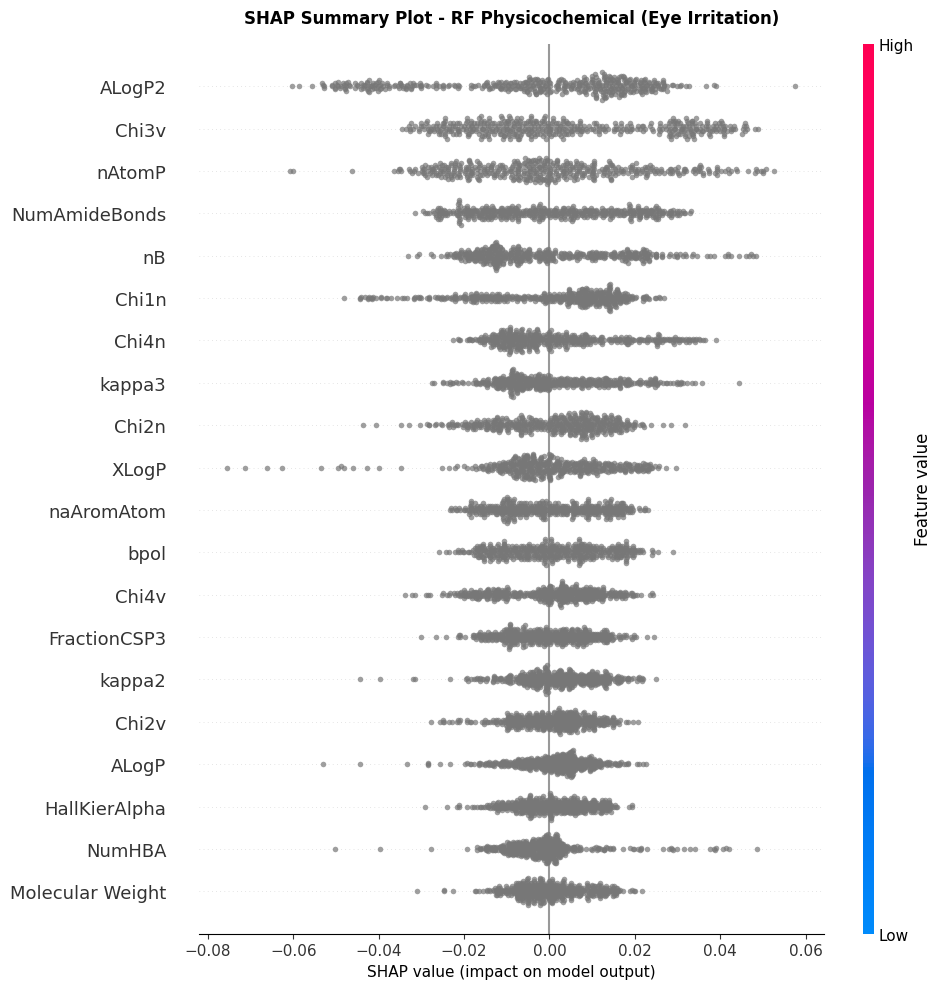

Plot tersimpan: shap_Eye.png


In [35]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature_names = ['Molecular Weight', 'logP',
       'LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD',
       'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v',
       'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha',
       'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', 'MLogP',
       'nAtomP', 'naAromAtom', 'bpol', 'nB', 'nHBAcc',
       'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB',
       'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3'
]

# Buat DataFrame
X_phys = pd.DataFrame(x_test_rdkit_cdk, columns=feature_names)

# Hitung SHAP values
print("Menghitung SHAP values RF...")
explainer_rf = shap.TreeExplainer(rf_p)
shap_values_rf = explainer_rf(X_phys)

print(f"Shape shap_values_rf.values: {shap_values_rf.values.shape}")

# Ambil class 1 kalau 3D
if len(shap_values_rf.values.shape) == 3:
    shap_vals = shap_values_rf.values[:, :, 1]
    print(f"Diambil class 1, shape final: {shap_vals.shape}")
else:
    shap_vals = shap_values_rf.values
    print(f"Shape final: {shap_vals.shape}")

# ===== FIX: buat Explanation object baru dengan data yang benar =====
shap_explanation = shap.Explanation(
    values=shap_vals,
    base_values=shap_values_rf.base_values[:, 1] if len(shap_values_rf.base_values.shape) > 1 
                else shap_values_rf.base_values,
    data=X_phys.values,           # <-- ini yang fix warna
    feature_names=feature_names
)

# ===== Summary Plot =====
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_explanation,             # <-- pakai Explanation object, bukan raw array
    X_phys,
    plot_type="dot",
    max_display=20,
    show=False,
    alpha=0.7,
    plot_size=None
)
plt.title("SHAP Summary Plot - RF Physicochemical (Eye Irritation)",
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel("SHAP value (impact on model output)", fontsize=11)
plt.tight_layout()
plt.savefig("shap_Eye.png", dpi=300, bbox_inches='tight')
plt.show()
print("Plot tersimpan: shap_Eye.png")

Dtype setelah konversi:
float64    56
dtype: int64
Shape: (457, 56)

Menghitung SHAP values XGB...
Type: <class 'numpy.ndarray'>
Shape: (457, 56)
Shape final: (457, 56)


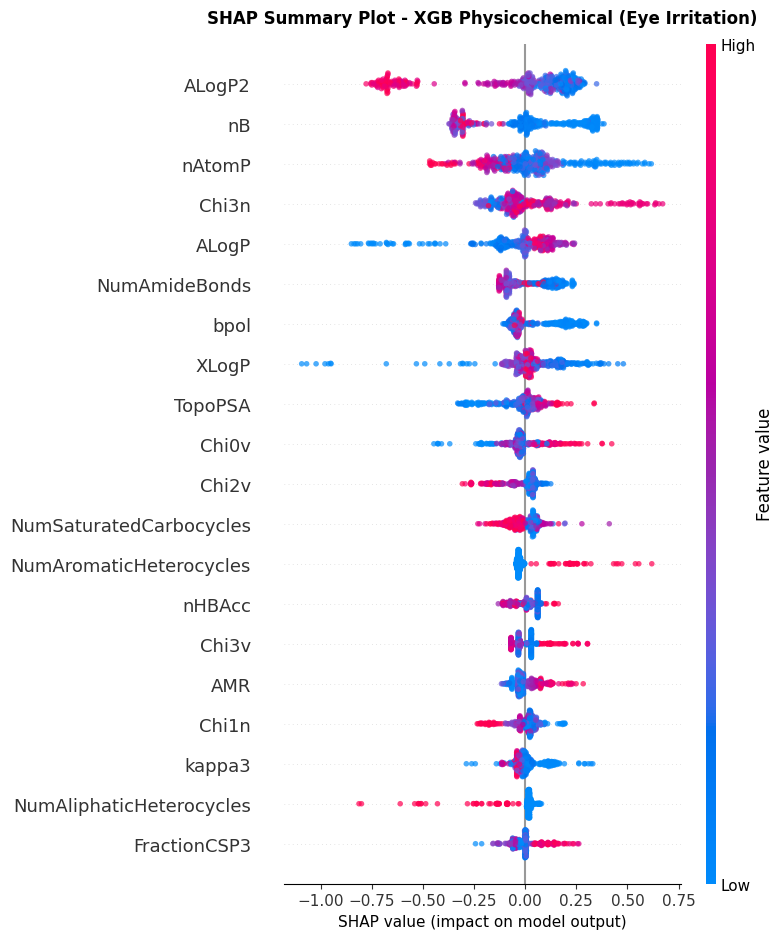

Plot tersimpan: shap_Eye_XGB.png


In [37]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature_names = ['Molecular Weight', 'logP',
       'LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD',
       'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v',
       'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha',
       'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', 'MLogP',
       'nAtomP', 'naAromAtom', 'bpol', 'nB', 'nHBAcc',
       'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB',
       'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3'
]

# ===== FIX: konversi eksplisit ke float64 =====
X_phys = pd.DataFrame(
    np.array(x_test_rdkit_cdk, dtype=np.float64),
    columns=feature_names
)

# Verifikasi dtype
print("Dtype setelah konversi:")
print(X_phys.dtypes.value_counts())
print(f"Shape: {X_phys.shape}")

# ===== XGBoost SHAP =====
print("\nMenghitung SHAP values XGB...")
explainer_xgb = shap.TreeExplainer(xgb_p)
shap_values_xgb = explainer_xgb.shap_values(X_phys)

print(f"Type: {type(shap_values_xgb)}")
print(f"Shape: {np.array(shap_values_xgb).shape}")

shap_vals = np.array(shap_values_xgb)
if len(shap_vals.shape) == 3:
    shap_vals = shap_vals[:, :, 1]

print(f"Shape final: {shap_vals.shape}")

# ===== Summary Plot =====
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_vals,
    X_phys,
    plot_type="dot",
    max_display=20,
    show=False,
    alpha=0.7
)
plt.title("SHAP Summary Plot - XGB Physicochemical (Eye Irritation)",
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel("SHAP value (impact on model output)", fontsize=11)
plt.tight_layout()
plt.savefig("shap_Eye_XGB.png", dpi=300, bbox_inches='tight')
plt.show()
print("Plot tersimpan: shap_Eye_XGB.png")

Dtype setelah konversi:
float64    56
dtype: int64
Shape: (457, 56)

Menghitung SHAP values XGB...
Type: <class 'numpy.ndarray'>
Shape: (457, 56)
Shape final: (457, 56)


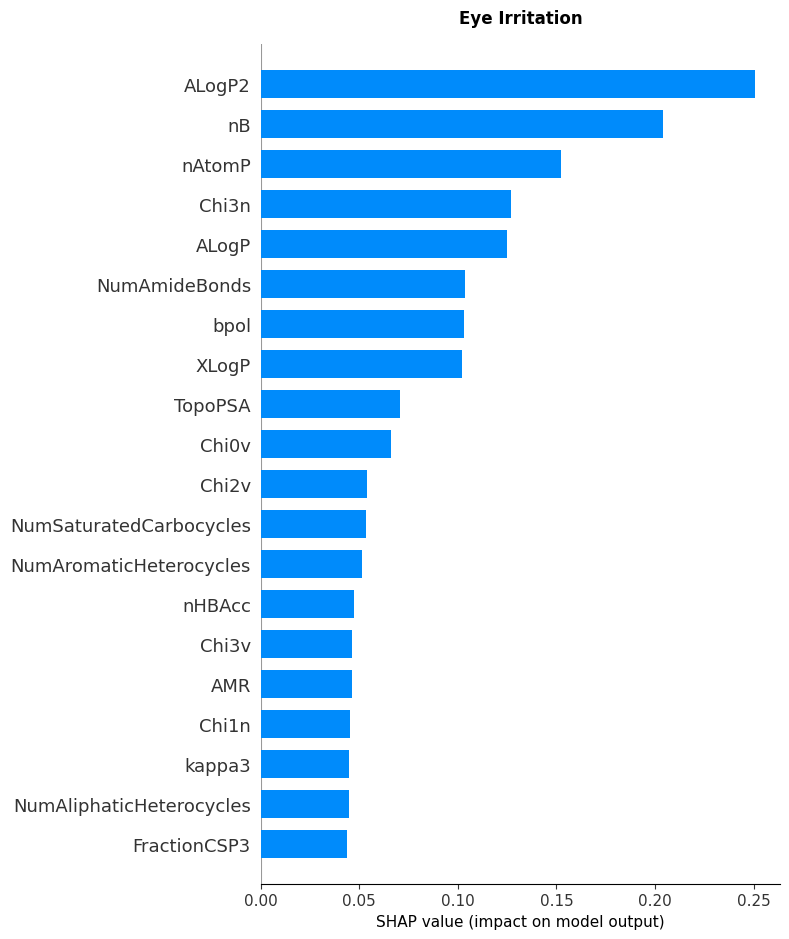

Plot tersimpan: shap_Eye_bar.png


In [39]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature_names = ['Molecular Weight', 'logP',
       'LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD',
       'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v',
       'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha',
       'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', 'MLogP',
       'nAtomP', 'naAromAtom', 'bpol', 'nB', 'nHBAcc',
       'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB',
       'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3'
]

# ===== FIX: konversi eksplisit ke float64 =====
X_phys = pd.DataFrame(
    np.array(x_test_rdkit_cdk, dtype=np.float64),
    columns=feature_names
)

# Verifikasi dtype
print("Dtype setelah konversi:")
print(X_phys.dtypes.value_counts())
print(f"Shape: {X_phys.shape}")

# ===== XGBoost SHAP =====
print("\nMenghitung SHAP values XGB...")
explainer_xgb = shap.TreeExplainer(xgb_p)
shap_values_xgb = explainer_xgb.shap_values(X_phys)

print(f"Type: {type(shap_values_xgb)}")
print(f"Shape: {np.array(shap_values_xgb).shape}")

shap_vals = np.array(shap_values_xgb)
if len(shap_vals.shape) == 3:
    shap_vals = shap_vals[:, :, 1]

print(f"Shape final: {shap_vals.shape}")

# ===== Summary Plot =====
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_vals,
    X_phys,
    plot_type="bar",
    max_display=20,
    show=False,
    alpha=0.7
)
plt.title("Eye Irritation",
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel("SHAP value (impact on model output)", fontsize=11)
plt.tight_layout()
plt.savefig("shap_Eye_bar.png", dpi=300, bbox_inches='tight')
plt.show()
print("Plot tersimpan: shap_Eye_bar.png")